In [1]:
import torchvision
from torchvision import transforms
import torch
from torchtune.datasets import ConcatDataset 

In [2]:
transformer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ToTensor()
])

In [3]:
datadir = "/kaggle/input/fruit-recognition/train/train"
data_set = torchvision.datasets.ImageFolder(datadir, transformer)
data_set.classes


['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [4]:
x, y = data_set[15]

x

tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000,  ..., 0.9961, 0.9961, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 0.9961],
         [1.0000, 1.0000, 0.9961,  ..., 1.0000, 0.9961, 0.9922]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 0.9961,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 0.9961, 1.0000, 0.9961],
         [1.0000, 1.0000, 1.0000,  ..., 0.9882, 0.9922, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.

In [5]:
len(data_set)

16854

In [6]:
from torch.utils.data import random_split

train_dataset, test_dataset = random_split(data_set, [0.8, 0.2])
print(len(test_dataset))
len(train_dataset)


3370


13484

In [9]:
from torch.utils.data import DataLoader


batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [10]:
for x, y in train_loader:
    break

y

tensor([25, 13,  0, 21,  4, 12, 12,  8, 12,  9, 24, 21, 25,  4, 23,  0, 25, 30,
        11, 10, 23, 15,  5,  5, 16, 20, 22, 11, 24,  5, 27,  5, 31,  6, 20, 12,
        21,  7, 15, 23, 12, 25,  7,  9, 31, 14, 24, 23, 23, 32, 18,  6, 32,  4,
         7,  5, 12,  8,  5, 12,  9, 10, 22, 27, 24,  5, 25,  6,  5, 12,  2, 31,
        24, 10, 31,  1,  4, 28,  4,  8,  8,  3,  5, 28, 26, 29,  0, 32,  4, 25,
         5, 21, 23, 28,  7, 18,  6,  5, 13, 22, 27, 29,  4, 19, 28, 32, 14, 26,
        18, 13, 26, 12,  2,  5, 11, 21, 14, 16, 20, 18, 21, 17,  4, 25,  3,  0,
        23,  6])

In [11]:
x.shape

torch.Size([128, 3, 64, 64])

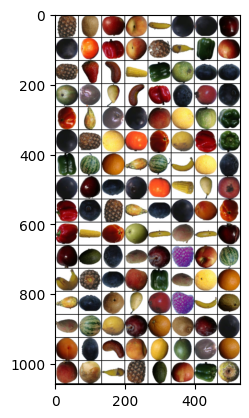

In [12]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


grid = make_grid(x).permute(1, 2, 0)

plt.imshow(grid)